<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/AI_KimBanjang_onsite_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 김반장 — 현장 학습형 이상탐지 검증

## 핵심 질문
**"각 모터(베어링)의 정상 상태만 현장에서 학습하면, 그 모터에 결함이 생겼을 때 탐지할 수 있는가?"**

## 두 가지 검증
| 검증 | 내용 | 중요도 |
|------|------|--------|
| **검증 1 (핵심)** | 정상 베어링 자기검증: 각 K00x의 60%로 베이스라인 → 나머지 40% 정상이 정상으로 잡히나? | ★★★ |
| **검증 2 (참고)** | 정상 베이스라인 대비 결함 베어링이 이상으로 잡히나? (개체가 달라 방증 수준) | ★★ |

## 핵심 확인 포인트
**K002 자기유지율** — cross-bearing에서 recall 2%로 망했던 K002가,
자기 자신을 베이스라인으로 삼으면 90%+로 살아나는가?

- 살아나면 → **현장 학습형 컨셉 유효** (문제는 K002가 아니라 "남의 정상으로 판단"이었음이 증명)
- 살아나지 않으면 → 특징 공간 자체 재설계 필요

## 사전 조건
- 어제 변환한 `Paderborn_iis3dwb` 재사용 (재변환 없음)
- **지도학습 모델 없음** — 통계 기반(Mahalanobis) 이상탐지만 사용
- 셀 0 먼저 실행 후 셀 1 실행

In [1]:
# ============================================================
# 셀 0. 드라이브 마운트 & 패키지 & 전역 상수
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn matplotlib scipy

import os, json
import numpy as np
from scipy.signal import hilbert, butter, sosfiltfilt
from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ★ 경로 — 어제 변환 결과 재사용
OUT_DIR  = '/content/drive/My Drive/Colab Notebooks/Paderborn_iis3dwb'
SAVE_DIR = '/content/drive/My Drive/Colab Notebooks/AI_KimBanjang_binary'

# 도메인 파라미터 (고정)
FS_IN         = 64000.0
RESAMPLE_UP   = 5
RESAMPLE_DOWN = 12
FS_OUT        = FS_IN * RESAMPLE_UP / RESAMPLE_DOWN  # 26666.6667 Hz
SENSITIVITY   = 0.000488   # g/LSB
WINDOW        = 2048
EVAL_HOP      = 2048
SEED          = 42

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'FS_OUT = {FS_OUT:.4f} Hz')
print(f'Window = {WINDOW} samples = {WINDOW/FS_OUT*1000:.1f} ms')
print(f'OUT_DIR 존재 여부: {os.path.isdir(OUT_DIR)}')

Mounted at /content/drive
FS_OUT = 26666.6667 Hz
Window = 2048 samples = 76.8 ms
OUT_DIR 존재 여부: True


[EXTRACT] 베어링별 특징 추출 중...
  정상 베어링: ['K001', 'K002', 'K003', 'K004', 'K005', 'K006']
  결함 베어링: 26종
    K001: 4162개 윈도우
    K002: 4172개 윈도우
    K003: 4165개 윈도우
    K004: 4162개 윈도우
    K005: 4166개 윈도우
    K006: 4164개 윈도우

 검증 1: 정상 베어링 자기검증 (현장 베이스라인 등록 안정성)
 임계값 = 베이스라인 정상 거리 99 percentile
베어링            베이스라인       테스트         자기정상유지%      판정
--------------------------------------------------------------------
K001            2497      1665           99.8%    PASS
K002            2503      1669          100.0%    PASS
K003            2499      1666           99.6%    PASS
K004            2497      1665          100.0%    PASS
K005            2499      1667          100.0%    PASS
K006            2498      1666           99.6%    PASS
--------------------------------------------------------------------
  평균 자기정상유지율: 99.8%  (90%+ 이면 현장등록 안정)
  ★ K002 자기유지율 : 100.0%
    (기존 cross-bearing에서는 recall 2% — 여기서 90%+면 컨셉 성립)

 검증 2 (참고): 정상 전체 베이스라인 → 결함 이상탐지력
 (정상/결함이 다른 개체라 한계 있음 — 방증 수준으로 해석

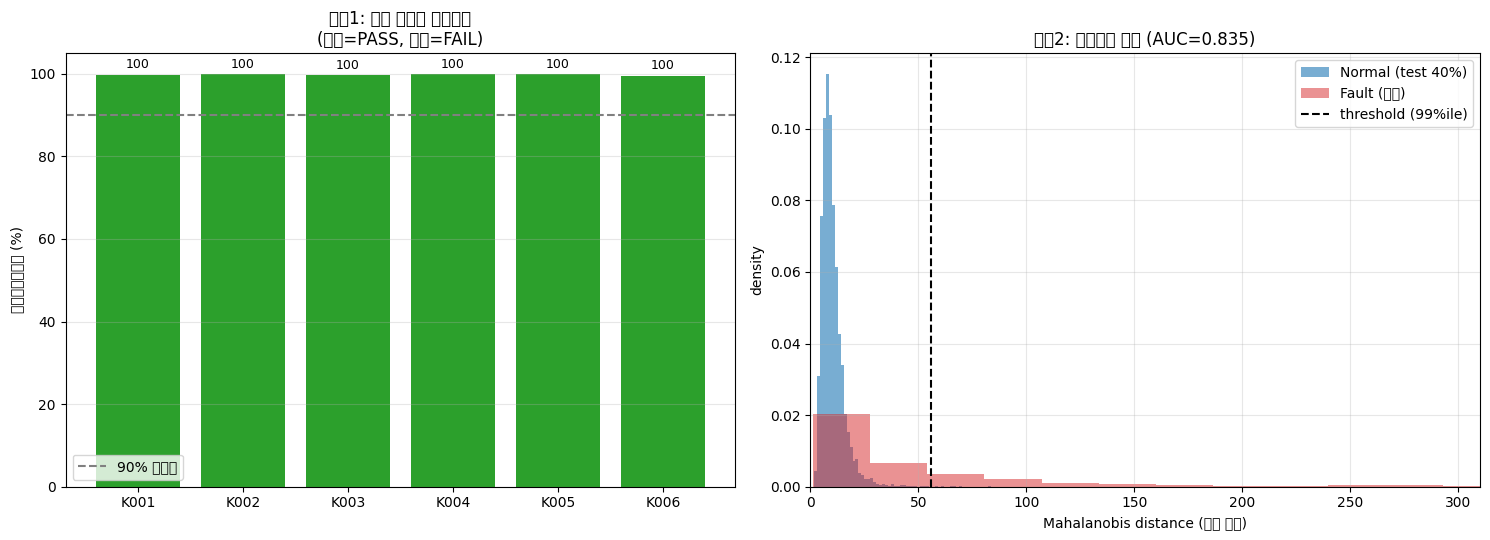


[SAVE] /content/drive/My Drive/Colab Notebooks/AI_KimBanjang_binary/onsite_baseline_validation.png

 종합 판정
  [검증1] 정상 자기유지 평균 99.8%,  K002 100.0%  → OK
  [검증2] 결함탐지 AUC 0.835  → 미흡
--------------------------------------------------------------------
  △ 자기검증 통과(현장등록 안정), 결함탐지 방증은 약함.
    → 개체가 다른 결함이라 당연할 수 있음.
    → run-to-failure 데이터(IMS, PRONOSTIA)로 재검증 권장.

[한계 안내]
  이 검증이 통과해도 제품 완성이 아님.
  Paderborn으로는 "정상 베이스라인 등록이 개체차를 극복한다"까지만 증명.
  실제 "정상→고장 조기탐지" 능력은 run-to-failure 데이터로 별도 검증 필요.
  (IMS, PRONOSTIA/FEMTO 등 — 다음 단계)


In [2]:
# ============================================================
# 셀 1. 현장 학습형 이상탐지 검증
# ★ 지도학습 없음. Mahalanobis 거리 기반 통계 이상탐지.
# ============================================================

DIAG_HOP = EVAL_HOP  # 2048 non-overlap
rng      = np.random.default_rng(SEED)

# ── 포락선 밴드패스 (전역 1회 생성) ──
_env_bp = butter(4, [500, 6000], btype='band', fs=FS_OUT, output='sos')

def extract_features(x):
    n       = len(x)
    rms     = np.sqrt(np.mean(x**2)) + 1e-12
    peak    = np.max(np.abs(x))
    crest   = peak / rms
    kurt    = kurtosis(x, fisher=True)
    sk      = skew(x)
    p2p     = np.ptp(x)
    shape   = rms / (np.mean(np.abs(x)) + 1e-12)
    impulse = peak / (np.mean(np.abs(x)) + 1e-12)
    xb      = sosfiltfilt(_env_bp, x)
    env     = np.abs(hilbert(xb)); env = env - np.mean(env)
    ef      = np.abs(rfft(env * np.hanning(n)))
    freqs   = rfftfreq(n, d=1.0/FS_OUT)
    tot     = np.sum(ef) + 1e-12
    band_e  = [np.sum(ef[(freqs>=lo)&(freqs<hi)]) / tot
               for lo, hi in [(10,100),(100,300),(300,600),(600,1000)]]
    sp      = np.abs(rfft(x * np.hanning(n)))
    sp_n    = sp / (np.sum(sp) + 1e-12)
    spec_centroid = np.sum(freqs * sp_n)
    spec_entropy  = -np.sum(sp_n * np.log(sp_n + 1e-12))
    return np.array([rms, crest, kurt, sk, shape, impulse, p2p,
                     *band_e, spec_centroid, spec_entropy], dtype=np.float64)

def windows_from_counts(counts_int16, hop):
    x   = counts_int16.astype(np.float64) * SENSITIVITY
    out = []
    for s in range(0, len(x) - WINDOW + 1, hop):
        seg = x[s:s+WINDOW]
        out.append(seg - np.mean(seg))
    return out

# ── manifest 로드 + 베어링별 특징 수집 ──
manifest_path = os.path.join(OUT_DIR, 'manifest.json')
assert os.path.isfile(manifest_path), f'manifest.json 없음: {manifest_path}'
with open(manifest_path, encoding='utf-8') as f:
    manifest = json.load(f)

print('[EXTRACT] 베어링별 특징 추출 중...')
bearing_feats = {}
for m in manifest:
    b   = m['bearing']
    npy = os.path.join(OUT_DIR, m['out'])
    if not os.path.isfile(npy):
        continue
    counts = np.load(npy)
    for w in windows_from_counts(counts, DIAG_HOP):
        fv = extract_features(w)
        if np.all(np.isfinite(fv)):
            bearing_feats.setdefault(b, []).append(fv)

for b in bearing_feats:
    bearing_feats[b] = np.array(bearing_feats[b])

normal_bearings = sorted([b for b in bearing_feats if b.startswith('K0')])
fault_bearings  = sorted([b for b in bearing_feats if not b.startswith('K0')])
print(f'  정상 베어링: {normal_bearings}')
print(f'  결함 베어링: {len(fault_bearings)}종')
for b in normal_bearings:
    print(f'    {b}: {len(bearing_feats[b])}개 윈도우')

# ── Mahalanobis 이상탐지기 ──
class BaselineDetector:
    """정상 특징으로 평균/공분산 학습 → Mahalanobis 거리로 이상 점수."""
    def fit(self, X_normal):
        self.scaler = StandardScaler()
        Xs          = self.scaler.fit_transform(X_normal)
        self.cov    = EmpiricalCovariance()
        self.cov.fit(Xs)
        self.d_train = self.cov.mahalanobis(Xs)
        return self

    def score(self, X):
        Xs = self.scaler.transform(X)
        return self.cov.mahalanobis(Xs)

    def threshold(self, q=99.0):
        return np.percentile(self.d_train, q)

# ============================================================
# 검증 1 (핵심): 정상 베어링 자기검증
# 앞 60% 윈도우 → 베이스라인 / 뒤 40% → 테스트
# ============================================================
print('\n' + '='*68)
print(' 검증 1: 정상 베어링 자기검증 (현장 베이스라인 등록 안정성)')
print(' 임계값 = 베이스라인 정상 거리 99 percentile')
print('='*68)
print(f'{"베어링":8}  {"베이스라인":>10}  {"테스트":>8}  {"자기정상유지%":>14}  {"판정":>6}')
print('-'*68)

self_pass = {}
for b in normal_bearings:
    X      = bearing_feats[b]
    n      = len(X)
    n_base = int(n * 0.6)
    Xb, Xt = X[:n_base], X[n_base:]
    if len(Xb) < 5 or len(Xt) < 1:
        print(f'{b:8}  윈도우 부족 — 건너뜀')
        continue
    det  = BaselineDetector().fit(Xb)
    thr  = det.threshold(q=99.0)
    d_t  = det.score(Xt)
    keep = np.mean(d_t <= thr) * 100
    ok   = 'PASS' if keep >= 90 else 'FAIL'
    self_pass[b] = keep
    print(f'{b:8}  {n_base:>10}  {len(Xt):>8}  {keep:>13.1f}%  {ok:>6}')

mean_keep = np.mean(list(self_pass.values()))
k002_keep = self_pass.get('K002', float('nan'))
print('-'*68)
print(f'  평균 자기정상유지율: {mean_keep:.1f}%  (90%+ 이면 현장등록 안정)')
print(f'  ★ K002 자기유지율 : {k002_keep:.1f}%')
print(f'    (기존 cross-bearing에서는 recall 2% — 여기서 90%+면 컨셉 성립)')

# ============================================================
# 검증 2 (참고): 정상 전체 베이스라인 → 결함 탐지력
# ============================================================
print('\n' + '='*68)
print(' 검증 2 (참고): 정상 전체 베이스라인 → 결함 이상탐지력')
print(' (정상/결함이 다른 개체라 한계 있음 — 방증 수준으로 해석)')
print('='*68)

Xbase, Xnorm_test = [], []
for b in normal_bearings:
    X      = bearing_feats[b]
    n_base = int(len(X) * 0.6)
    Xbase.append(X[:n_base])
    Xnorm_test.append(X[n_base:])
Xbase      = np.vstack(Xbase)
Xnorm_test = np.vstack(Xnorm_test)

det_all = BaselineDetector().fit(Xbase)
thr_all = det_all.threshold(q=99.0)

d_norm = det_all.score(Xnorm_test)
far    = np.mean(d_norm > thr_all) * 100

print(f'  정상 오탐율 (FAR @99% 임계): {far:.1f}%')
print()
print(f'{"결함베어링":10}  {"윈도우":>8}  {"탐지율%":>10}')
print('-'*32)

fault_scores_all, fault_detect = [], []
for b in fault_bearings:
    Xf       = bearing_feats[b]
    df       = det_all.score(Xf)
    det_rate = np.mean(df > thr_all) * 100
    fault_detect.append(det_rate)
    fault_scores_all.append(df)
    print(f'{b:10}  {len(Xf):>8}  {det_rate:>9.1f}%')

fault_scores_all = np.concatenate(fault_scores_all)
mean_detect      = np.mean(fault_detect)

y_true  = np.concatenate([np.zeros(len(d_norm)), np.ones(len(fault_scores_all))])
y_score = np.concatenate([d_norm, fault_scores_all])
auc     = roc_auc_score(y_true, y_score)

print('-'*32)
print(f'  결함 평균 탐지율 : {mean_detect:.1f}%')
print(f'  ROC-AUC           : {auc:.3f}  (1.0=완벽, 0.5=무의미)')

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (1) 정상 베어링별 자기유지율
ax     = axes[0]
bs     = list(self_pass.keys())
vals   = list(self_pass.values())
colors = ['#2ca02c' if v >= 90 else '#d62728' for v in vals]
ax.bar(bs, vals, color=colors)
ax.axhline(90, ls='--', c='gray', label='90% 기준선')
ax.set_ylim(0, 105)
ax.set_ylabel('자기정상유지율 (%)')
ax.set_title('검증1: 정상 베어링 자기검증\n(초록=PASS, 빨강=FAIL)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(vals):
    ax.text(i, v + 1.5, f'{v:.0f}', ha='center', fontsize=9)

# (2) 이상점수 분포: 정상 test vs 결함
ax = axes[1]
clip_max = np.percentile(fault_scores_all, 98)
ax.hist(d_norm,           bins=60, alpha=0.6, color='#1f77b4',
        density=True, label='Normal (test 40%)')
ax.hist(fault_scores_all, bins=60, alpha=0.5, color='#d62728',
        density=True, label='Fault (전체)')
ax.axvline(thr_all, ls='--', c='k', label=f'threshold (99%ile)')
ax.set_xlim(0, clip_max)
ax.set_xlabel('Mahalanobis distance (이상 점수)')
ax.set_ylabel('density')
ax.set_title(f'검증2: 이상점수 분포 (AUC={auc:.3f})')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
save_png = os.path.join(SAVE_DIR, 'onsite_baseline_validation.png')
plt.savefig(save_png, dpi=150)
plt.show()
print(f'\n[SAVE] {save_png}')

# ── 종합 판정 ──
c1 = (mean_keep >= 90) and (k002_keep >= 90)
c2 = (auc >= 0.85)

print('\n' + '='*68)
print(' 종합 판정')
print('='*68)
print(f'  [검증1] 정상 자기유지 평균 {mean_keep:.1f}%,  K002 {k002_keep:.1f}%  '
      f'→ {"OK" if c1 else "미흡"}')
print(f'  [검증2] 결함탐지 AUC {auc:.3f}  → {"OK" if c2 else "미흡"}')
print('-'*68)
if c1 and c2:
    print('  ✅ 현장 학습형 컨셉 유효.')
    print('     K002 문제(개체차)가 현장 베이스라인으로 해소됨.')
    print('     → 다음: 실시간 베이스라인 등록 + 이탈경보 알고리즘 상세설계.')
elif c1 and not c2:
    print('  △ 자기검증 통과(현장등록 안정), 결함탐지 방증은 약함.')
    print('    → 개체가 다른 결함이라 당연할 수 있음.')
    print('    → run-to-failure 데이터(IMS, PRONOSTIA)로 재검증 권장.')
elif not c1 and c2:
    print('  △ 결함은 잘 분리되나, 정상 자기검증 미흡.')
    print('    → 특징 설계 또는 임계값 전략 재검토 필요.')
else:
    print('  ❌ 자기검증 미흡. 특징/임계값 재설계 필요.')
    print('    K002가 자기검증에서도 FAIL이면 특징공간 자체를 바꿔야 함.')
print('='*68)
print()
print('[한계 안내]')
print('  이 검증이 통과해도 제품 완성이 아님.')
print('  Paderborn으로는 "정상 베이스라인 등록이 개체차를 극복한다"까지만 증명.')
print('  실제 "정상→고장 조기탐지" 능력은 run-to-failure 데이터로 별도 검증 필요.')
print('  (IMS, PRONOSTIA/FEMTO 등 — 다음 단계)')